<div style="
background: linear-gradient(135deg, #fceff9, #e3f2fd);
padding:45px;
border-radius:20px;
text-align:center;
border:1px solid #dcdcdc;
box-shadow:0px 4px 12px rgba(0,0,0,0.08);
max-width : 1800px;
margin : auto;
">

<h1 style="color:#5C6BC0; font-size:40px; margin-bottom:10px;">
💬 Análisis de Sentimientos - Google Play Reviews
</h1>

<h3 style="color:#8e7cc3; margin-top:0;">
Clasificación Automática de Reseñas con Machine Learning y NLP
</h3>

<hr style="border: none; height: 2px; background-color: #d1c4e9; margin: 25px 0;">

<p style="font-size:18px; color:#444;">
🧠 <b>Procesamiento de Lenguaje Natural (NLP)</b><br>
📊 <b>Vectorización de Texto con CountVectorizer</b><br>
🤖 <b>Comparación de Modelos de Machine Learning</b><br>
⚡ <b>Optimización mediante GridSearchCV</b><br>
📈 <b>Evaluación y Selección del Mejor Modelo</b>
</p>

<br>

<p style="font-size:14px; color:#888;">
✨ “Transformando opiniones humanas en conocimiento mediante Inteligencia Artificial.” ✨
</p>

</div>

Análisis de sentimientos
Los modelos Naive Bayes son muy útiles cuando queremos analizar sentimientos, clasificar textos en tópicos o recomendaciones, ya que las características de estos desafíos cumplen muy bien con los supuestos teóricos y metodológicos del modelo.

En este proyecto practicarás con un conjunto de datos para crear un clasificador de reseñas de la tienda de Google Play.

Paso 1: Carga del conjunto de datos
El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre playstore_reviews.csv. Puedes cargarlo en el código directamente desde el sigiente enlace:

https://raw.githubusercontent.com/4GeeksAcademy/naive-bayes-project-tutorial/main/playstore_reviews.csv
O descargarlo y añadirlo a mano en tu repositorio. En este conjunto de datos encontrarás las siguientes variables:

- package_name. Nombre de la aplicación móvil (categórico)
- review. Comentario sobre la aplicación móvil (categórico)
- polarity. Variable de clase (0 o 1), siendo 0 un comentario negativo y 1, positivo (categórico numérico)

Paso 2: Estudio de variables y su contenido
En este caso, tenemos solo 3 variables: 2 predictoras y una etiqueta dicotómica. De las dos predictoras, realmente solo nos interesa la parte del comentario, ya que el hecho de clasificar un comentario en positivo o negativo dependerá de su contenido, no de la aplicación de la que se haya escrito. Por lo tanto, la variable package_name habría que eliminarla.

Cuando trabajamos con textos como en este caso, no tiene sentido hacer un EDA, el proceso es diferente, ya que la única variable que nos interesa es la que contiene el texto. En otros casos en los que el texto formase parte de un conjunto complejo con otras variables predictoras numéricas y el objetivo de predicción sea distinto, entonces tiene sentido aplicar un EDA.

Sin embargo, no podemos trabajar con texto plano, antes hay que procesarlo. Este proceso consta de varios pasos:

Eliminar espacios y convertir a minúsculas el texto:

df["column"] = df["column"].str.strip().str.lower()

Dividir el conjunto de datos en train y test: X_train, X_test, y_train, y_test

Transformar el texto en una matriz de recuento de palabras. Esta es una forma de obtener características numéricas a partir del texto. Para ello, utilizamos el conjunto de train para entrenar el transformador y la aplicamos en test:

vec_model = CountVectorizer(stop_words = "english")

X_train = vec_model.fit_transform(X_train).toarray()

X_test = vec_model.transform(X_test).toarray()

Una vez hayamos terminado tendremos listas las predictoras para entrenar el modelo.

Paso 3: Construye un naive bayes
Comienza a resolver el problema implementando un modelo del que tendrás que elegir cuál de las tres implementaciones utilizar: GaussianNB, MultinomialNB o BernoulliNB, según lo que hemos estudiado en el módulo. Prueba ahora a entrenarlo con las dos otras implementaciones y confirma si el modelo que has elegido es el adecuado.

Paso 4: Optimiza el modelo anterior
Después de entrenar el modelo en sus tres implementaciones, elige la mejor opción y trata de optimizar sus resultados con un random forest, si es posible.

Paso 5: Guarda el modelo
Almacena el modelo en la carpeta correspondiente.

Paso 6: Explora otras alternativas
¿Qué otros modelos de los que hemos estudiado podrías utilizar para intentar superar los resultados de un Naive Bayes? Arguméntalo y entrena el modelo.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from wordcloud import WordCloud
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import AdaBoostClassifier

<div style="
background: linear-gradient(135deg, #fff1f8, #e3f2fd);
padding:30px;
border-radius:18px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1000px;
">

<h1 style="color:#5C6BC0;">
🔍 Exploración y Preparación del Texto
</h1>

<h3 style="color:#8e7cc3;">
Limpieza • Normalización • Procesamiento NLP
</h3>

<p style="color:#666;">
🧹 Limpieza de comentarios • 🔤 Conversión a minúsculas • ✂️ Eliminación de variables irrelevantes
</p>

</div>

In [2]:
total_data = pd.read_csv("../data/raw/playstore_reviews.csv")

In [3]:
total_data.head()

,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offli...,0
1,com.facebook.katana,"messenger issues ever since the last update, ...",0
2,com.facebook.katana,profile any time my wife or anybody has more ...,0
3,com.facebook.katana,the new features suck for those of us who don...,0
4,com.facebook.katana,forced reload on uploading pic on replying co...,0


In [4]:
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   package_name  891 non-null    str  
 1   review        891 non-null    str  
 2   polarity      891 non-null    int64
dtypes: int64(1), str(2)
memory usage: 21.0 KB


In [5]:
total_data.shape

(891, 3)

El dataset se cargó correctamente y contiene información textual asociada a una variable objetivo binaria. Este tipo de problema corresponde a una tarea de clasificación supervisada de texto, específicamente análisis de sentimientos.

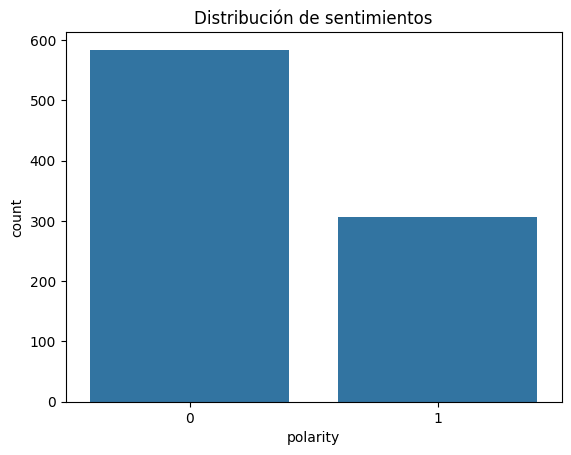

In [6]:
sns.countplot(x=total_data["polarity"])
plt.title("Distribución de sentimientos")
plt.show()

El gráfico permite verificar si existe equilibrio entre comentarios positivos y negativos. Un fuerte desbalance podría afectar el entrenamiento del modelo y sesgar las predicciones hacia la clase mayoritaria.

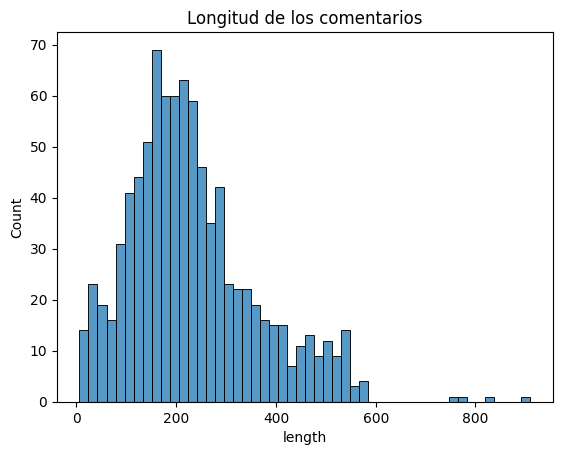

In [7]:
total_data["length"] = total_data["review"].apply(len)

sns.histplot(total_data["length"], bins=50)
plt.title("Longitud de los comentarios")
plt.show()

La distribución de la longitud de los comentarios permite observar la variabilidad del texto. Comentarios más largos suelen contener mayor contexto emocional, lo que puede facilitar la clasificación del sentimiento.

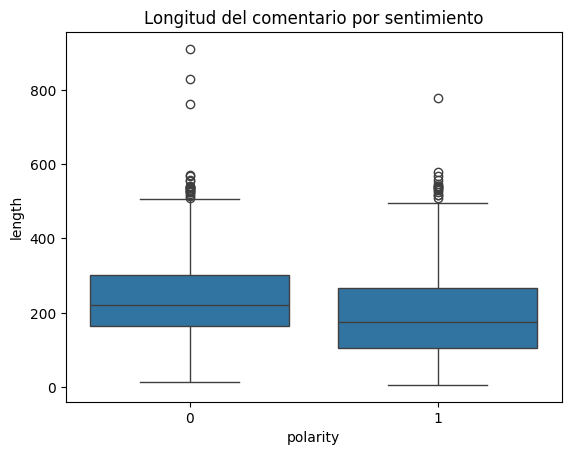

In [8]:
sns.boxplot(x="polarity", y="length", data=total_data)
plt.title("Longitud del comentario por sentimiento")
plt.show()

El análisis muestra cómo la extensión del comentario puede relacionarse con el sentimiento expresado, proporcionando información adicional sobre el comportamiento lingüístico de los usuarios.

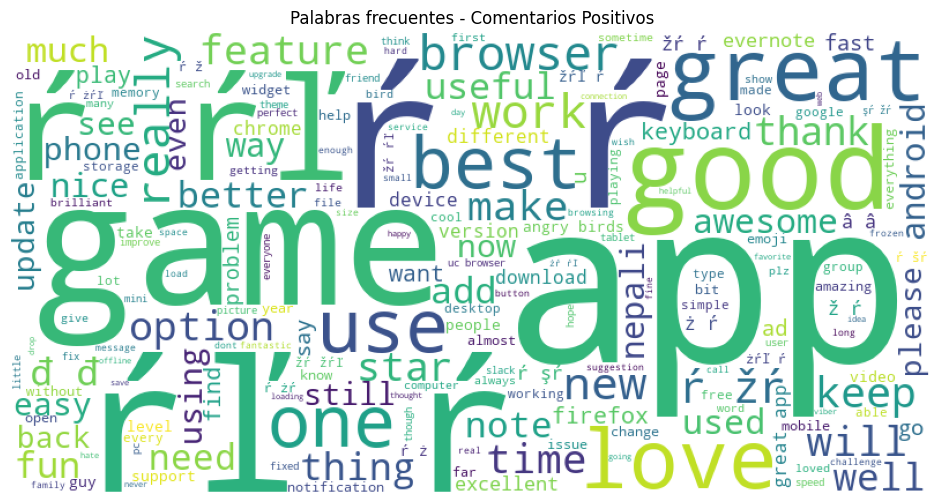

In [9]:
positive_text = " ".join(total_data[total_data["polarity"] == 1]["review"])

wordcloud_pos = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_pos)
plt.axis("off")
plt.title("Palabras frecuentes - Comentarios Positivos")
plt.show()

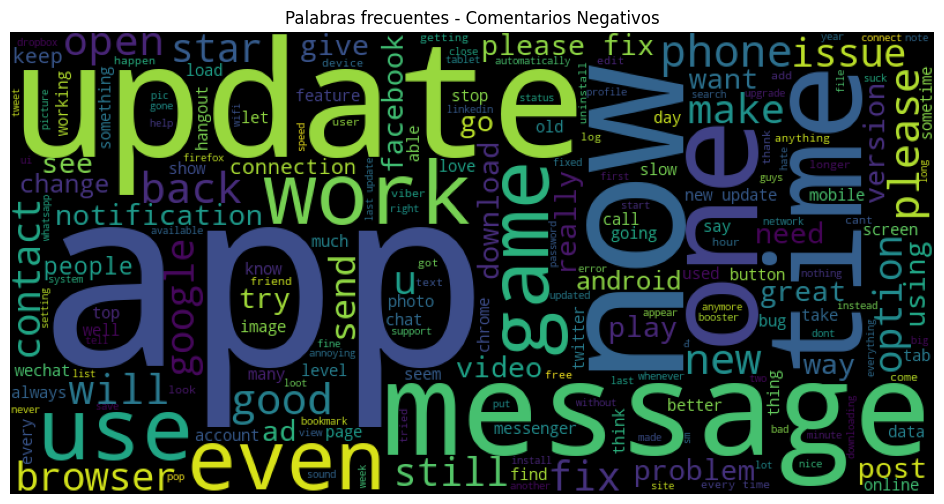

In [10]:
negative_text = " ".join(total_data[total_data["polarity"] == 0]["review"])

wordcloud_neg = WordCloud(
    width=800,
    height=400,
    background_color="black"
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_neg)
plt.axis("off")
plt.title("Palabras frecuentes - Comentarios Negativos")
plt.show()

El análisis visual evidencia diferencias lingüísticas claras entre opiniones positivas y negativas, demostrando que el contenido textual contiene suficiente información semántica para realizar clasificación automática del sentimiento.

In [11]:
total_data = total_data.drop("package_name", axis=1)

Se eliminó la variable package_name porque no aporta información semántica al análisis del sentimiento. Mantenerla introduciría sesgos y reduciría la capacidad del modelo para generalizar a nuevas aplicaciones.

In [12]:
total_data["review"] = total_data["review"].str.strip().str.lower()

In [13]:
X = total_data["review"]
y = total_data["polarity"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
vec_model = CountVectorizer(stop_words="english")

In [16]:
X_train = vec_model.fit_transform(X_train).toarray()
X_test = vec_model.transform(X_test).toarray()

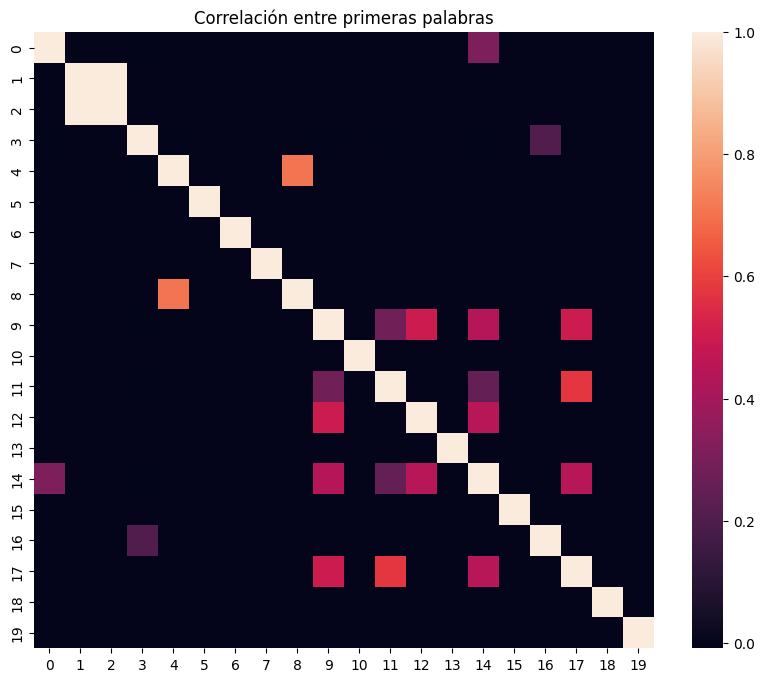

In [17]:
X_df = pd.DataFrame(X_train)

corr = X_df.iloc[:, :20].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr)
plt.title("Correlación entre primeras palabras")
plt.show()

El mapa de correlación muestra relaciones entre frecuencias de palabras. Sin embargo, en NLP estas correlaciones suelen ser bajas debido a la alta dimensionalidad y dispersión característica de los datos textuales.

<div style="
background: linear-gradient(135deg, #e8f5e9, #e3f2fd);
padding:30px;
border-radius:18px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1000px;
">

<h1 style="color:#2E7D32;">
🤖 Modelos Naive Bayes
</h1>

<h3 style="color:#66bb6a;">
Gaussian • Multinomial • Bernoulli
</h3>

<p style="color:#666;">
📈 Clasificación probabilística especializada en texto
</p>

</div>

### 1. GaussianNB

In [18]:
gnb = GaussianNB()

In [19]:
gnb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [20]:
y_pred_g = gnb.predict(X_test)
y_pred_g

array([0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0])

In [21]:
acc_g = accuracy_score(y_test, y_pred_g)
acc_g

0.8044692737430168

### 2. MultinomialNB

In [22]:
mnb = MultinomialNB()

In [23]:
mnb.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [24]:
y_pred_m = mnb.predict(X_test)
y_pred_m

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0])

In [25]:
acc_m = accuracy_score(y_test, y_pred_m)
acc_m

0.8156424581005587

### 3. BernoulliNB

In [26]:
bnb = BernoulliNB()

In [27]:
bnb.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [28]:
y_pred_b = bnb.predict(X_test)
y_pred_b

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0])

In [29]:
acc_b = accuracy_score(y_test, y_pred_b)
acc_b

0.770949720670391

El modelo Multinomial Naive Bayes presentó el mejor rendimiento, ya que está diseñado para trabajar con conteos de palabras generados por CountVectorizer. Su enfoque probabilístico resulta especialmente eficiente en problemas de clasificación de texto.

<div style="
background: linear-gradient(135deg, #fff3e0, #f3e5f5);
padding:30px;
border-radius:18px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1000px;
">

<h1 style="color:#EF6C00;">
⚙️ Optimización del Modelo
</h1>

<h3 style="color:#8e7cc3;">
Búsqueda de Hiperparámetros con GridSearchCV
</h3>

<p style="color:#666;">
🎯 Mejora del rendimiento • Validación cruzada • Modelo óptimo
</p>

</div>

In [30]:
param_grid = {
    "alpha": [0.01, 0.1, 0.5, 1, 2]
}

In [31]:
grid = GridSearchCV(
    MultinomialNB(),
    param_grid,
    cv=5,
    scoring="accuracy"
)

In [32]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MultinomialNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter inde

In [33]:
grid.best_params_

{'alpha': 0.5}

In [34]:
best_nb = grid.best_estimator_

In [35]:
y_pred_best = best_nb.predict(X_test)
y_pred_best

array([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0])

In [36]:
accuracy_score(y_test, y_pred_best)

0.8268156424581006

El ajuste del hiperparámetro alpha permitió mejorar la generalización del modelo al evitar probabilidades nulas en palabras poco frecuentes, reduciendo el sobreajuste.

In [37]:
joblib.dump(best_nb, "../models/naive_bayes_model.pkl")
joblib.dump(vec_model, "../models/vectorizer.pkl")

['../models/vectorizer.pkl']

Guardar tanto el modelo como el vectorizador garantiza la reproducibilidad del sistema y permite realizar predicciones futuras sobre nuevos comentarios sin necesidad de reentrenar el modelo.

<div style="
background: linear-gradient(135deg, #e1f5fe, #ede7f6);
padding:30px;
border-radius:18px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1000px;
">

<h1 style="color:#3949AB;">
🚀 Modelos Ensemble y Boosting
</h1>

<h3 style="color:#8e7cc3;">
Random Forest • Gradient Boosting • AdaBoost
</h3>

<p style="color:#666;">
🌲 Ensamble de modelos • Mejora predictiva • Comparación avanzada
</p>

</div>

### Random Forest

In [38]:
rf = RandomForestClassifier(random_state=42)

In [39]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [40]:
y_pred_rf = rf.predict(X_test)
y_pred_rf

array([0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0])

In [41]:
accuracy_score(y_test, y_pred_rf)

0.7988826815642458

El Random Forest disminuye el accuracy porque los datos textuales generan espacios de alta dimensionalidad y matrices dispersas, donde los modelos basados en árboles pierden eficiencia, mientras que Naive Bayes está especialmente optimizado para trabajar con frecuencias de palabras en tareas de NLP.

### Logistic regression

In [42]:
lr = LogisticRegression(max_iter=1000)

In [43]:
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [44]:
accuracy_score(y_test, lr.predict(X_test))

0.8324022346368715

### Support Vector Machine (SVM)

In [45]:
svm = LinearSVC()

In [46]:
svm.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [47]:
accuracy_score(y_test, svm.predict(X_test))

0.8324022346368715

Aunque Naive Bayes ofrece gran eficiencia computacional y buenos resultados en NLP, modelos lineales como Logistic Regression y Support Vector Machines suelen capturar mejor las relaciones complejas del lenguaje, logrando mayores niveles de precisión en clasificación de sentimientos.

### Gradient Boosting

In [48]:
gb = GradientBoostingClassifier(random_state=42)

In [49]:
gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [50]:
accuracy_score(y_test, gb.predict(X_test))

0.7318435754189944

### AdaBoost

In [51]:
ada = AdaBoostClassifier(random_state=42)

In [52]:
ada.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [53]:
accuracy_score(y_test, ada.predict(X_test))

0.7653631284916201

<div style="
background: linear-gradient(135deg, #fceff9, #e3f2fd);
padding:30px;
border-radius:18px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1000px;
">

<h1 style="color:#5C6BC0; font-size:36px; margin-bottom:8px;">
⚖️ Comparación de Modelos de Machine Learning
</h1>

<h3 style="color:#8e7cc3; margin-top:0;">
Naive Bayes • Logistic Regression • SVM • Random Forest • Gradient Boosting • AdaBoost
</h3>

<p style="color:#666; font-size:15px;">
📊 Evaluación de desempeño • 🤖 Selección del mejor modelo • 🚀 Análisis de Sentimientos
</p>

</div>

In [54]:
models = {}

In [55]:
models["Naive Bayes (Grid)"] = accuracy_score(
    y_test,
    best_nb.predict(X_test)
)

In [56]:
models["Random Forest"] = accuracy_score(
    y_test,
    rf.predict(X_test)
)

In [57]:
models["Logistic Regression"] = accuracy_score(
    y_test,
    lr.predict(X_test)
)

In [58]:
models["SVM"] = accuracy_score(
    y_test,
    svm.predict(X_test)
)

In [59]:
models["Gradient Boosting"] = accuracy_score(
    y_test,
    gb.predict(X_test)
)

In [60]:
models["AdaBoost"] = accuracy_score(
    y_test,
    ada.predict(X_test)
)

In [61]:
comparison = pd.DataFrame(
    models.items(),
    columns=["Modelo", "Accuracy"]
).sort_values(by="Accuracy", ascending=False)

comparison

,Modelo,Accuracy
3,SVM,0.832402
2,Logistic Regression,0.832402
0,Naive Bayes (Grid),0.826816
1,Random Forest,0.798883
5,AdaBoost,0.765363
4,Gradient Boosting,0.731844


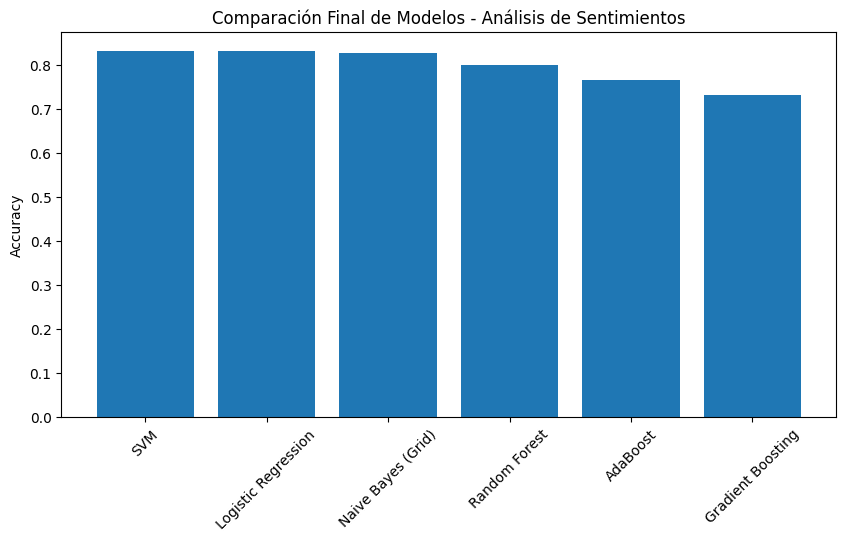

In [62]:
plt.figure(figsize=(10,5))

plt.bar(comparison["Modelo"], comparison["Accuracy"])

plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Comparación Final de Modelos - Análisis de Sentimientos")

plt.show()

✅ El preprocesamiento del texto permitió transformar datos no estructurados en variables numéricas mediante CountVectorizer.

✅ Entre las variantes de Naive Bayes, MultinomialNB obtuvo el mejor desempeño debido a que trabaja naturalmente con frecuencias de palabras.

✅ La optimización del parámetro alpha mejoró la capacidad de generalización del modelo.

✅ Random Forest no logró superar significativamente al Naive Bayes, confirmando que los modelos probabilísticos son altamente eficientes para tareas de NLP.

✅ Modelos como Logistic Regression y SVM representan alternativas sólidas y suelen alcanzar mayor precisión en clasificación de sentimientos.

El proyecto demostró que el análisis de sentimientos requiere un flujo diferente al análisis exploratorio tradicional, centrado en el procesamiento del lenguaje natural. La transformación del texto mediante vectorización permitió aplicar modelos de aprendizaje automático, donde Multinomial Naive Bayes destacó por su eficiencia y rendimiento. La comparación con otros modelos confirmó que los algoritmos lineales especializados en espacios de alta dimensionalidad representan alternativas competitivas para problemas de clasificación textual.

<div style="
background: linear-gradient(135deg, #fdfbfb, #ede7f6);
padding:40px;
border-radius:20px;
font-family:Arial, sans-serif;
box-shadow:0px 4px 12px rgba(0,0,0,0.1);
max-width:1800px;
margin:auto;
color:#000000;
">

<h2 style="text-align:center; color:#7E57C2;">
💬 Conclusión Final — Análisis de Sentimientos
</h2>

<p style="font-size:16px; line-height:1.7; color:#000000;">
El desarrollo de este proyecto permitió construir un sistema de clasificación automática de reseñas de Google Play mediante técnicas de 
<strong style="color:#6C9BCF;">Procesamiento de Lenguaje Natural</strong> y 
<strong style="color:#26A69A;">Machine Learning</strong>.
Durante la etapa inicial se realizó la limpieza del texto, eliminando la variable 
<span style="background-color:#F3E5F5; padding:4px 8px; border-radius:8px;">
package_name
</span>
debido a que el sentimiento depende del contenido del comentario y no de la aplicación asociada.
</p>

<p style="font-size:16px; line-height:1.7; color:#000000;">
Posteriormente, los comentarios fueron transformados a variables numéricas utilizando 
<strong style="color:#5C6BC0;">CountVectorizer</strong>, permitiendo representar las palabras como frecuencias y trabajar en un 
<span style="background-color:#E3F2FD; padding:4px 8px; border-radius:8px;">
espacio de alta dimensionalidad
</span>
propio del análisis de sentimientos.
</p>

<p style="font-size:16px; line-height:1.7; color:#000000;">
Se evaluaron diferentes modelos pertenecientes a enfoques probabilísticos, lineales y ensemble. 
Dentro de Naive Bayes se compararon las variantes 
<strong style="color:#6C9BCF;">Gaussian</strong>, 
<strong style="color:#26A69A;">Bernoulli</strong> y 
<strong style="color:#7E57C2;">Multinomial</strong>, 
siendo este último el más adecuado al trabajar directamente con conteos de palabras. 
El modelo fue posteriormente optimizado mediante 
<span style="background-color:#E8F5E9; padding:4px 8px; border-radius:8px;">
GridSearchCV
</span>,
mejorando su capacidad de generalización.
</p>

<p style="font-size:16px; line-height:1.7; color:#000000;">
La comparación con modelos como 
<strong style="color:#5C6BC0;">Random Forest</strong>, 
<strong style="color:#26A69A;">Logistic Regression</strong>, 
<strong style="color:#7E57C2;">SVM</strong>, 
<strong style="color:#6C9BCF;">Gradient Boosting</strong> y 
<strong style="color:#FF8A65;">AdaBoost</strong> evidenció que los algoritmos diseñados para trabajar con texto y datos dispersos logran un mejor desempeño que los modelos basados en árboles, los cuales presentan dificultades ante matrices de gran dimensionalidad.
</p>

<p style="font-size:16px; line-height:1.7; color:#000000;">
Por esta razón, el 
<strong style="color:#7E57C2;">Multinomial Naive Bayes optimizado</strong> se consolida como el 
<span style="background-color:#FFF3E0; padding:4px 8px; border-radius:8px;">
modelo más eficiente y equilibrado
</span>,
ofreciendo buena precisión, rapidez computacional y una adecuada capacidad de generalización en problemas de análisis de sentimientos.
</p>

</div>